# LAB 02: NAVIE BAYES CLASSIFICATION
## A. Phuong phap Gaussian navie bayes voi du lieu lien tuc 

### vi du 1. Phan loai bo du lieu hoa IRIS
- ộ dữ liệu hoa IRIS có thể lấy từ link sau (tệp excel csv): http://archive.ics.uci.edu/ml/datasets/Iris (hoặc
tệp Iris.data – dạng văn bản kèm theo bài thực hành).
- Do dữ liệu vào là số thực, vì vậy chúng ta sẽ phải dùng phương pháp Gaussian Naïve Bayes (tự xem
lại phần lý thuyết).
- Để đơn giản trước hết ta chỉ căn cứ vào độ dài cánh hoa để phân loại. Các bước tính toán theo lý thuyết
(sử dụng phương pháp ước lượng hợp lý cực đại – MLE):
- Chúng ta có thể giải bằng 02 thư viện, numpy và scikit-learning. Chú ý bộ dữ liệu IRIS khá chuẩn
mực trong việc sử dụng làm minh họa cho bài toán classification, do đó có thể load từ thư viện của
python.

In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import seaborn as sns 
import itertools 
from scipy.stats import norm 
import scipy.stats
from sklearn.naive_bayes import GaussianNB 
%matplotlib inline
sns.set()

#### Su dung Numpy 

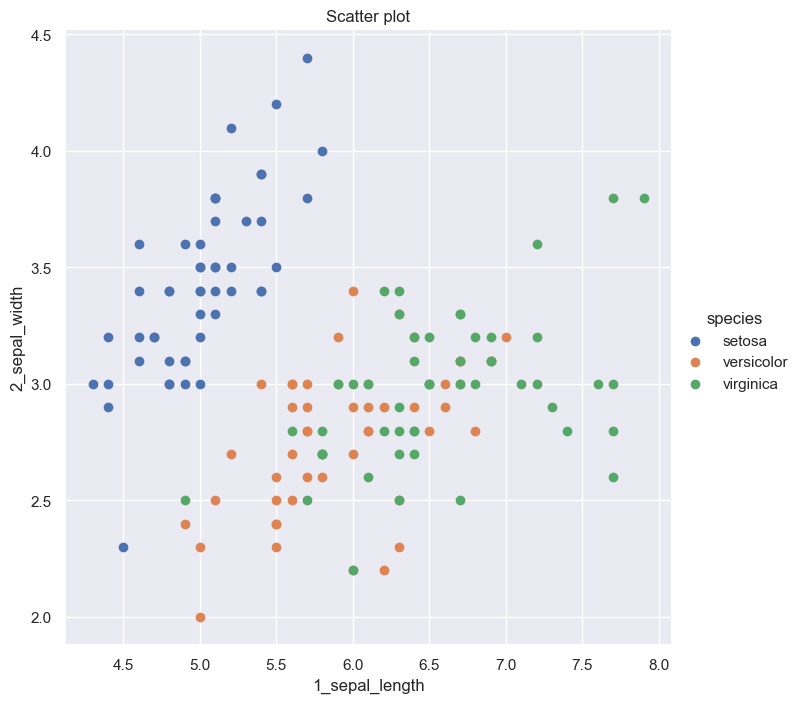

In [3]:
# load the data set
iris = sns.load_dataset("iris")
iris = iris.rename(index = str, columns = {'sepal_length':'1_sepal_length','sepal_width':'2_sepal_width'
                                        , 'petal_length':'3_petal_length', 'petal_width':'4_petal_width'})

# plot the scatter of sepal length vs sepal width
sns.FacetGrid(iris, hue = "species", height = 7).map(plt.scatter, "1_sepal_length", "2_sepal_width").add_legend()
plt.title("Scatter plot")
df1 = iris[["1_sepal_length", "2_sepal_width",'species']]



- Xử lý bằng phương pháp Gaussian Naïve Bayes dùng thư viện Numpy và Pandas

In [4]:
def predict_NB_gaussian_class(X, mu_list, std_list, pi_list):
    # #Trả về lớp mà hàm mục tiêu Naive Bayes Gauss có giá trị lớn nhất
    # Ta sẽ sử dụng thư viện scipy để tính P(x|c) norm.pdf or multivariate_norm.pdf() 
    score_list = []
    classes = len(mu_list)
    for p in range(classes):
        # score la xác suất hậu nhiệm argmax(P(x|c) * P(c)) 
        # norm.pdf(...) Đây là Gaussian probability density function tức là P(xi​∣y=p)
        # Để đơn giản ta chỉ căn cứ vào độ dài cánh hoa để phân loại tức là feature 1 và 2
        # sepal length , sepal width 
        # x[0] feature 1, x[1] feature 2
        # mu_list : mean của P 
        # mu_list[p][0][0] nghĩa là class mean có dạng [[[m1, m2]]] 
        # tương tự std_list 
        # gia định các vecto độc lập với nhau 
        score = (norm.pdf(x = X[0], loc = mu_list[p][0][0], scale = std_list[p][0][0] )
        * norm.pdf(x = X[1], loc = mu_list[p][0][1], scale = std_list[p][0][1] )
        * pi_list[p])
    
        score_list.append(score)

    # np.argmax: trả về vị trí của phần tử có giá trị lớn nhất 
    
    return np.argmax(score_list)

def predict_Bayes_class(X, mu_list, sigma_list):
    # Trả về lớp dự đoán từ optimal bayes classifier 
    # - các phân phối phải được biết trước
    scores_list = []
    classes = len(mu_list)
    # trường hợp các feature có mối liên qua mạnh với nhau, cần cov: ma trận hiệp phương sai 
    # tính P(x∣y=p)
    for p in range(classes):
        score = scipy.stats.multivariate_normal.pdf(X, mean=mu_list[p], cov=sigma_list[p])
        scores_list.append(score)
    return np.argmax(scores_list)
    

- In và vẽ kết quả ra màn hình (chú ý đoạn này có thể phát sinh lỗi do thiếu thư viện)

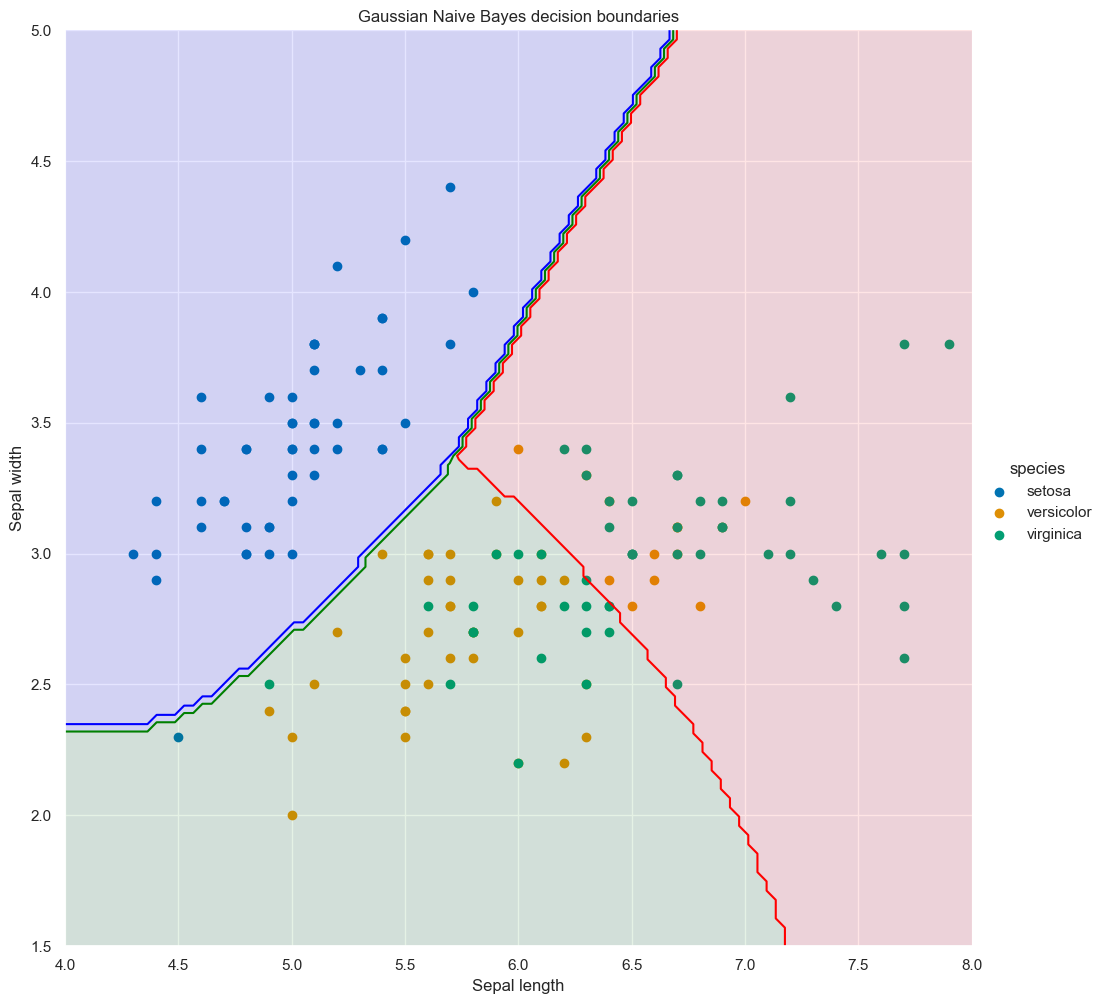

In [5]:
#Estimating the parameters ( ước tính các tham số, mean, độ lêch chuẩn) 
# [1,2] nghĩa là cắt tại index = 1, index = 2 => cắt thành 3 phần 

mu_list = np.split(df1.groupby('species').mean().values,[1,2])
std_list = np.split(df1.groupby('species').std().values,[1,2], axis = 0)
pi_list = df1.iloc[:,2].value_counts().values / len(df1)

# Our 2-dimensional distribution will be over variables X and Y
# # Phân phối hai chiều của chúng ta sẽ dựa trên các biến X và Y
N = 100
# Tao 100 diem tu 4, 8
X = np.linspace(4, 8, N)
Y = np.linspace(1.5, 5, N)
# tao ma tran x, y 
X, Y = np.meshgrid(X, Y)

# fig = plt.figure(figsize = (10,10))
# ax = fig.gca()
color_list = ['Blues','Greens','Reds']
my_norm = colors.Normalize(vmin=-1.,vmax=1.)
g = sns.FacetGrid(iris, hue="species", height =10, palette = 'colorblind') .map(plt.scatter, "1_sepal_length", "2_sepal_width",) .add_legend()
    
my_ax = g.ax
#Computing the predicted class function for each value on the grid
#Tính toán hàm dự đoán lớp cho mỗi giá trị trên lưới
# X, Y là meshgrid (100x100)

# np.ravel(X) → flatten thành vector 10000 phần tử tương tự với Y 
# zip(...) → tạo từng điểm:

zz = np.array( [predict_NB_gaussian_class( np.array([xx,yy]).reshape(-1,1), mu_list, std_list, pi_list)
for xx, yy in zip(np.ravel(X), np.ravel(Y)) ] )
#Reshaping the predicted class into the meshgrid shape
# #Định hình lại lớp dự đoán thành hình dạng lưới [[]]
Z = zz.reshape(X.shape)
#Plot the filled and boundary contours
# x, y lưới tọa độ, z class tại mỗi điểm, alpha độ trong suốt, màu 

my_ax.contourf( X, Y, Z, 2, alpha = .1, colors = ('blue','green','red'))
my_ax.contour( X, Y, Z, 2, alpha = 1, colors = ('blue','green','red'))
# Addd axis and title
my_ax.set_xlabel('Sepal length')
my_ax.set_ylabel('Sepal width')
my_ax.set_title('Gaussian Naive Bayes decision boundaries')
plt.show()

#### Su dung Scikit-learning 


/tmp/ipykernel_8622/3519553977.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_labels = df1.iloc[:,2].replace({'setosa':0,'versicolor':1,'virginica':2}).copy()


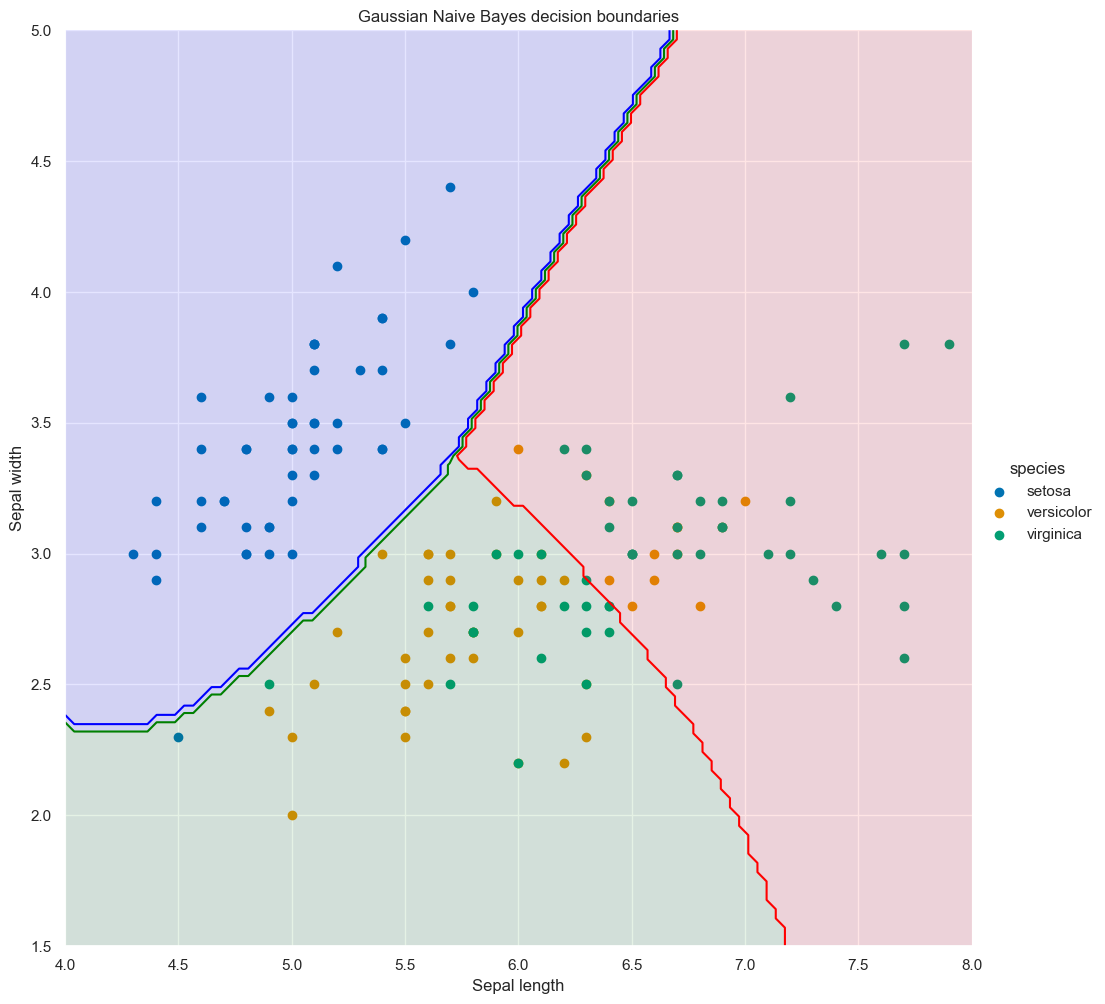

In [6]:
from sklearn.naive_bayes import GaussianNB 

#Setup X and y data
X_data = df1.iloc[:,0:2].values 
y_labels = df1.iloc[:,2].replace({'setosa':0,'versicolor':1,'virginica':2}).copy()

# Fit model 
model_sk = GaussianNB(priors = None) 
model_sk.fit(X_data, y_labels)

# Our 2-dimensional classifier will be over variables X and Y
N = 100
X = np.linspace(4, 8, N)
Y = np.linspace(1.5, 5, N)
X, Y = np.meshgrid(X, Y)


color_list = ['Blues','Greens','Reds']
my_norm = colors.Normalize(vmin=-1.,vmax=1.)
g = sns.FacetGrid(iris, hue="species", height=10, palette = 'colorblind') .map(plt.scatter, "1_sepal_length", "2_sepal_width",) .add_legend()
my_ax = g.ax
#Computing the predicted class function for each value on the grid
zz = np.array( [model_sk.predict( [[xx,yy]])[0] for xx, yy in zip(np.ravel(X), np.ravel(Y)
) ] )
#Reshaping the predicted class into the meshgrid shape
Z = zz.reshape(X.shape)
#Plot the filled and boundary contours
my_ax.contourf( X, Y, Z, 2, alpha = .1, colors = ('blue','green','red'))
my_ax.contour( X, Y, Z, 2, alpha = 1, colors = ('blue','green','red'))
# Addd axis and title
my_ax.set_xlabel('Sepal length')
my_ax.set_ylabel('Sepal width')
my_ax.set_title('Gaussian Naive Bayes decision boundaries')

plt.show()

#### Bai tap mo rong: 
- Hãy mở rộng phần code đã có, để thực hiện phân loại với đầu vào là đủ 04 thuộc tính
của dữ liệu. Chia tập dữ liệu thành train:test theo tỉ lệ 4:1, huấn luyện và dự đoán trên tập test, sau đó tính
độ chính xác theo các chỉ số (độ đo) đã học

In [ ]:
from sklearn.model_selection import train_test_split

In [16]:
df2 = iris

# chia tap du lieu thanh train test
X_data = df2.iloc[:, 0:4]
y_labels = df2["species"]

# Chia du lieu su dung thu vien sklearn
# X_train, X_test, y_train, y_test = train_test_split(
    # X_data, y_labels, test_size=0.2, random_state=42)
    
# Chia du lieu su dung thu vien pandas 
# Shuffle dataset : xáo chộn dữ liệu 
df2_shuffled = df2.sample(frac=1, random_state=42)
#frac = 1 lay 100% du lieu
# random_state la seed: giu nguyen kieu du lieu khi chay lai

# Tính điểm chia
split_index = int(0.8 * len(df2))

# Train
train_df = df2_shuffled.iloc[:split_index]

# Test
test_df = df2_shuffled.iloc[split_index:]

# Tách X và y
X_train = train_df.iloc[:, 0:4]
y_train = train_df.iloc[:, 4]

X_test = test_df.iloc[:, 0:4]
y_test = test_df.iloc[:, 4]


##### Su dung thu vien numpy, pandas

In [20]:
#Estimating the parameters ( ước tính các tham số, mean, độ lêch chuẩn) 
# [1,2] nghĩa là cắt tại index = 1, index = 2 => cắt thành 3 phần 

mu_list = np.split(train_df.groupby('species').mean().values,[1,2])
std_list = np.split(train_df.groupby('species').std().values,[1,2], axis = 0)
pi_list = train_df.iloc[:,4].value_counts().values / len(train_df)

In [27]:
def predict_NB_gaussian_class(X, mu_list, std_list, pi_list):
    # #Trả về lớp mà hàm mục tiêu Naive Bayes Gauss có giá trị lớn nhất
    # Ta sẽ sử dụng thư viện scipy để tính P(x|c) norm.pdf or multivariate_norm.pdf() 
    score_list = []
    classes = len(mu_list)
    for p in range(classes):
        # score la xác suất hậu nhiệm argmax(P(x|c) * P(c)) 
        # norm.pdf(...) Đây là Gaussian probability density function tức là P(xi​∣y=p)
        # Để đơn giản ta chỉ căn cứ vào độ dài cánh hoa để phân loại tức là feature 1 và 2
        # sepal length , sepal width 
        # x[0] feature 1, x[1] feature 2
        # mu_list : mean của P 
        # mu_list[p][0][0] nghĩa là class mean có dạng [[[m1, m2]]] 
        # tương tự std_list 
        # gia định các vecto độc lập với nhau 
        score = (norm.pdf(x = X[0], loc = mu_list[p][0][0], scale = std_list[p][0][0] )
        * norm.pdf(x = X[1], loc = mu_list[p][0][1], scale = std_list[p][0][1] )
        * norm.pdf(x = X[2], loc = mu_list[p][0][2], scale = std_list[p][0][2])
        * norm.pdf(x = X[3], loc = mu_list[p][0][3], scale = std_list[p][0][3])
        * pi_list[p])
    
        score_list.append(score)
    return np.argmax(score_list)

In [34]:

# Ap dung tren tap test
predictions = []
# Duyệt qua từng dòng trong tập test

for index, row in test_df.iterrows():
    X_row = np.array(row.iloc[:4])
    
    # Gọi hàm dự đoán
    pred_class_index = predict_NB_gaussian_class(X_row, mu_list, std_list, pi_list)
    predictions.append(pred_class_index)

# Copy test_df sang một biến mới để gán dữ liệu không bị văng warning (SettingWithCopyWarning)
test_results = test_df.copy()

# Thêm cột dự đoán (dạng số 0, 1, 2)
test_results['predicted_index'] = predictions

# Ánh xạ từ index (0, 1, 2) về lại tên loài hoa tương ứng
# Hàm groupby() phía trên của mày sẽ tự động sắp xếp tên hoa theo bảng chữ cái
# Nên thứ tự mặc định sẽ là: 0 -> setosa, 1 -> versicolor, 2 -> virginica
class_mapping = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
test_results['predicted_species'] = test_results['predicted_index'].map(class_mapping)

# Tính độ chính xác (Accuracy)
# Giả sử cột thứ 5 (index 4) là cột chứa nhãn thực tế (species)
actual_species = test_df.iloc[:, 4]
correct_predictions = (actual_species == test_results['predicted_species']).sum()
accuracy = correct_predictions / len(test_results)

print(f"--- KẾT QUẢ TRÊN TẬP TEST ---")
print(f"Số mẫu dự đoán đúng: {correct_predictions} / {len(test_results)}")
print(f"Độ chính xác (Accuracy): {accuracy * 100:.2f}%\n")

print("So sánh 5 dòng đầu tiên:")
print(test_results.iloc[:, [4, -1]].head())

--- KẾT QUẢ TRÊN TẬP TEST ---
Số mẫu dự đoán đúng: 28 / 30
Độ chính xác (Accuracy): 93.33%

So sánh 5 dòng đầu tiên:
       species predicted_species
91  versicolor        versicolor
41      setosa            setosa
58  versicolor        versicolor
90  versicolor        versicolor
48      setosa            setosa


##### Su dung thu vien sklearn

In [43]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

y_pred = model_nb.predict(X_test)
print("\n--- ĐỘ CHÍNH XÁC (ACCURACY) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

print("--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---")
print(classification_report(y_test, y_pred))

# Vẽ Confusion Matrix bằng text cho nhanh
print("--- MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---")
print(confusion_matrix(y_test, y_pred))

result = pd.DataFrame({
    "y_test": y_test.values,  # Thêm .values để xóa index lộn xộn
    "y_pred": y_pred
})
print(result.head())



--- ĐỘ CHÍNH XÁC (ACCURACY) ---
Accuracy: 93.33%

--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         7
  versicolor       0.91      0.91      0.91        11
   virginica       0.92      0.92      0.92        12

    accuracy                           0.93        30
   macro avg       0.94      0.94      0.94        30
weighted avg       0.93      0.93      0.93        30

--- MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---
[[ 7  0  0]
 [ 0 10  1]
 [ 0  1 11]]
       y_test      y_pred
0  versicolor  versicolor
1      setosa      setosa
2  versicolor  versicolor
3  versicolor  versicolor
4      setosa      setosa


### Bai tap tu giai: Mo hinh phan loai Gaussian Navie Bayes 
- Tập dữ liệu phân loại bệnh nhân ung thư vú của Đại học Wisconsin–Madison, Hoa Kỳ tại link:
https://ftp.cs.wisc.edu/math-prog/cpo-dataset/machine-learn/cancer/cancer1/
Để dự đoán một bệnh nhân có khả năng ung thư hay không, người ta thu thập các mẫu sinh thiết, xét
nghiệm bằng việc lấy một lát cắt của mẫu để soi dưới kính hiển vi, quét và ghi lại mẫu dưới dạng các
khung ảnh số của các nhân tế bào. Từ đó, người ta tiến hành đo kích thước, hình dạng, kết cấu của chúng
và tính toán 10 đặc tính của nhân. Cụ thể trong tệp dữ liệu các trường sẽ là
1. Mã số mẫu
2. Loại: 2 cho lành tính, 4 cho ác tính (2 for benign, 4 for malignant)
3. Độ dày hạch (Clump Thickness)
4. Sự đồng nhất của kích thước tế bào (Uniformity of Cell Size)
5. Tính đồng nhất của hình dạng tế bào (Uniformity of Cell Shape)
6. Độ kết dính lề - biên (Marginal Adhesion)
7. Kích thước tế bào biểu mô đơn (Single Epithelial Cell Size)
8. Phần nhân ngoài (Bare Nuclei)
9. Chất nhiễm sắc thể (Bland Chromatin)
10. Nhân trong thường (Normal Nucleoli)
11. Vỏ (Mitoses)
- Tìm hiểu thêm về dữ liệu bằng cách đọc tệp data.doc trong cùng thư mục. Trong số 698 mẫu thu thập (tệp
datacum), người ta chia thành hai nhóm, u lành tính (B–benign) và u ác tính (M–malignant). Hãy tách dữ
liệu thành các phần như sau:
- Chọn 80 mẫu lành tính (Trường phân loại là 2) và 40 mẫu ác tính (Trường phân loại là 4) làm dữ
liệu Test, chúng ta sẽ không sử dụng trường phân loại. Phần còn lại sẽ là dữ liệu training.
- Sử dụng mô hình phân loại Naïve Bayes (chú ý dữ liệu quan sát là biến liên tục – cần chọn phương
pháp phù hợp) để lập chương trình thực hiện phân loại dựa trên dữ liệu training.
- Sau đó thực hiện việc kiểm chứng và so sánh độ chính xác theo các chỉ số Acurracy, Precision và
Recall. Có thể sử dụng thư viện, nhưng cần có giải thích rõ các phần chương trình.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score


In [62]:
# tim hieu ve du lieu
# Cach doc tep .data cung nhu cach doc tep .csv 
column_names = ['ID', 'Mitoses', 'Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape', 
                'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin', 'Normal Nucleoli', 'Class']
df = pd.read_csv('breast-cancer-wisconsin.data', header = None, names = column_names, na_values="?")
df

,ID,Mitoses,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
694,776715,3,1,1,1,3,2.0,1,1,1,2
695,841769,2,1,1,1,2,1.0,1,1,1,2
696,888820,5,10,10,3,7,3.0,8,10,2,4
697,897471,4,8,6,4,3,4.0,10,6,1,4


In [63]:
# Xu ly du lieu 
df.isnull().sum()

ID                              0
Mitoses                         0
Clump Thickness                 0
Uniformity of Cell Size         0
Uniformity of Cell Shape        0
Marginal Adhesion               0
Single Epithelial Cell Size    16
Bare Nuclei                     0
Bland Chromatin                 0
Normal Nucleoli                 0
Class                           0
dtype: int64

In [64]:
df = df.dropna()
df.isnull().sum()

ID                             0
Mitoses                        0
Clump Thickness                0
Uniformity of Cell Size        0
Uniformity of Cell Shape       0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Bland Chromatin                0
Normal Nucleoli                0
Class                          0
dtype: int64

In [69]:
# lay du lieu test 

benign = df[df['Class'] == 2]
malignant = df[df['Class'] == 4]

test_benign = benign.sample(80, random_state = 1)
test_malignant = malignant.sample(40, random_state = 2)
test_data = pd.concat([test_benign, test_malignant])

# lay du lieu training 
train_data = df.drop(test_data.index)

In [70]:
X_train = train_data.drop(['Class','ID'], axis=1) #Input training
y_train = train_data['Class'] #Nhãn huấn luyện

X_test = test_data.drop(['Class','ID'], axis=1) #Input test
y_test = test_data['Class'] #Nhãn thực tế 

model = GaussianNB() #Khởi tạo mô hình
model.fit(X_train, y_train) #Huấn luyện mô hình
y_pred = model.predict(X_test) #Nhãn dự đoán từ mô hình

In [71]:
print('Accuracy Score của mô hình: ', accuracy_score(y_pred, y_test))
print('Precision Score của mô hình: ', precision_score(y_pred, y_test, average = 'macro'))
print('Recall Score của mô hình: ', recall_score(y_pred, y_test, average = 'macro'))

Accuracy Score của mô hình:  0.9666666666666667
Precision Score của mô hình:  0.975
Recall Score của mô hình:  0.9545454545454546


## B. PHƯƠNG PHÁP NÄIVE BAYES CHO DỮ LIỆU RỜI RẠC

### MULTINOMIAL NAÏVE BAYES

#### Vi du 1: 
- Tệp dữ liệu multinomial_nb_orders.csv đính kèm chứa dữ liệu phi văn bản với các trường
dạng category (nhiều lựa chọn). Bối cảnh là đơn đặt món ăn online, cần dự đoán loại ẩm thực (cuisine)
từ nhiều thuộc tính rời rạc:
- Dữ liệu đầu vào gồm các trường:city (20 lựa chọn), device (5), user_segment (6), promo (8 +
“none” = 9 lựa chọn), fav_ingredient (20), spice_level (5), day_of_week (7), price_bucket (5).
- Nhãn cần dự báo: cuisine với 10 lớp (thai, vietnamese, indian, japanese, …, chinese).
- Hãy xây dựng chương trình thực hiện việc đọc dữ liệu từ tệp CSV, sau đó chia dữ liệu theo tỉ lệ train:test
= 7:3; Thực hiện huấn luyện bằng mô hình Multinomial Naïve Bayes trên tập Train và thực hiện dự đoán
cũng như đánh giá kết quả trên tập Test.
- Trong ví dụ này, chúng ta sẽ bám theo công thức lý thuyết và xây dựng các phương thức như MultiNomial
Naïve Bayes từ các thư viện cơ sở, do đó chúng ta chỉ cần các thư viện numpy cho tính toán; pandas để
đọc và xử lý dữ liệu; một số gói có độ đo đánh giá của sklearn. Đoạn sau đây khai báo thư việ

In [72]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [73]:
# Đọc tệp dữ liệu Cancer.csv trong file data_cancer
df = pd.read_csv('food_order.csv')
print(df.head() )

         cuisine     city       device user_segment    promo fav_ingredient  \
0       japanese  city_19          web      student  promo_8         sesame   
1        chinese   city_1          ios       budget  promo_5            soy   
2  mediterranean  city_14  desktop_app       family  promo_8         yogurt   
3        italian  city_15       tablet          new  promo_4          lemon   
4     vietnamese  city_10          ios          new  promo_8          basil   

  spice_level day_of_week price_bucket  
0      medium         Tue          mid  
1   extra_hot         Wed    very_high  
2        none         Mon          mid  
3        none         Sat          mid  
4        mild         Tue          mid  


- Dưới đây chúng ta tính các xác suất để một mẫu bất kỳ rơi vào lớp thứ k theo tiên nghiệm P(k) = Nk/N
(tương tự như bài sử dụng Gaussian NB phân loại hoa Iris). Đầu ra đoạn này sẽ là mảng 2 chiều Labels,
trong đó ứng với mỗi phần tử i, giá trị đầu (index 0) sẽ là tên của phân lớp đầu ra; giá trị sau (index 1) sẽ
là tỉ lệ số phần tử (xác suất) của phân lớp đó (P(k) ).

In [77]:
target_feature = 'cuisine'
Y = df[target_feature]
labels = np.zeros((len(set(Y)), 2), dtype=Y.dtype)
# Liệt kê các nhãn (label) khác nhau (từ trường cuisine) k =1, 2, ... C
# và tính xác suất P_k của mỗi nhãn. Sử dụng nhãn thay cho chỉ số
id = 0
for label in set(Y):
    labels[id, 0] = label
    labels[id, 1] = (Y == label).sum()/len(Y)
    id += 1
    
labels

array([['korean', np.float64(0.06766666666666667)],
       ['indian', np.float64(0.09733333333333333)],
       ['thai', np.float64(0.10666666666666667)],
       ['vietnamese', np.float64(0.10033333333333333)],
       ['american', np.float64(0.129)],
       ['japanese', np.float64(0.08566666666666667)],
       ['mexican', np.float64(0.09833333333333333)],
       ['chinese', np.float64(0.13233333333333333)],
       ['mediterranean', np.float64(0.07933333333333334)],
       ['italian', np.float64(0.10333333333333333)]], dtype=object)

##### Yeu cau tu giai
- Hãy bỏ qua phương thức này và lập 01 mảng để lưu số lựa chọn tối đa ứng với mỗi
trường dữ liệu theo thông tin ở đề bài.
- Sau đó chúng ta đếm xem mỗi trường có tối đa bao nhiêu lựa chọn từ tập huấn luyện. Chú ý phần này
hoàn toàn có thể thay bằng một mảng cố định, do chúng ta đã biết thông tin về dữ liệu ở phần trên.

In [78]:
def get_distinct_value_in_fields():
    # Get the column names as a Pandas Index object
    column_names_index = df.columns
    tmp_list = column_names_index.values
    num_nomials_per_fields = np.zeros((len(tmp_list ), 2), dtype=tmp_list.dtype)
    # Convert the Index object to a NumPy array
    num_nomials_per_fields[:, 0] = tmp_list
    for i in range(len(tmp_list)):
        X = df[tmp_list[i]]
        unique_elements = set(X)
        # Get the count of unique elements
        num_nomials_per_fields[i, 1] = len(unique_elements)
    return num_nomials_per_fields
num_labels_M = get_distinct_value_in_fields()
print(num_labels_M)

[['cuisine' 10]
 ['city' 20]
 ['device' 5]
 ['user_segment' 6]
 ['promo' 9]
 ['fav_ingredient' 18]
 ['spice_level' 5]
 ['day_of_week' 7]
 ['price_bucket' 4]]


- Su dung cong thuc xap xi Smooth Laplacian de tinh xac suat thanh phan 

In [79]:
def Pxik_feature_in_class(X, xi, num_nomials_M, alpha = 1.0):
    X = np.array(X)
    count = (X == xi).sum()
    return (count + alpha) / (len(X) + num_nomials_M * alpha)

In [81]:
# du doan dau ra 
def predict_output_label(X, x_input, p_labels, target_feature):
    num_labels_M = get_distinct_value_in_fields()
    # khoi tao xax suat piror y^, chuyen sang log 
    p = np.log(np.array(p_labels[:, 1], dtype = float))

    for k in range(len(p)):
        X_k = X[X[target_feature] == p_labels[k, 0]]
        for i in range(len(x_input)):
            p[k] += np.log(Pxik_feature_in_class(X_k.iloc[:, i + 1],
                                                 x_input.iloc[i],
                                                 num_labels_M[i + 1, 1]))
    y_star = np.argmax(p)
    return p_labels[y_star, 0]

In [82]:
# chia tap train test
train_size = round(len(df) * 0.7)
X_train = df[:train_size]
Y_train = df[target_feature][:train_size]

X_test = df[train_size:].drop(target_feature,
                               axis = 1).reset_index(drop = True,
                                                     inplace = False)
Y_test = df[target_feature][train_size:].reset_index(drop = True,
                                                     inplace = False)

Y_pred = np.zeros(len(Y_test), dtype = Y_test.dtype)

print(len(X_test), len(Y_test))
print(X_test.index, Y_test.index)

for i in range(len(X_test)):
    Y_pred[i] = predict_output_label(X_train, X_test.iloc[i, :],
                                     labels, target_feature)

900 900
RangeIndex(start=0, stop=900, step=1) RangeIndex(start=0, stop=900, step=1)


In [83]:
print(accuracy_score(Y_pred, Y_test))
print(precision_score(Y_pred, Y_test, average = 'macro'))
print(recall_score(Y_pred, Y_test, average = 'macro'))
print(predict_output_label(X_train, X_train.iloc[3, 1:], labels, target_feature)) 

0.4711111111111111
0.4386144592149896
0.44046155451365454
italian


##### Bai tap 1: Su dung thu vien Sklearn  

In [85]:
# one hot encoding: bien du lieu dang chu thanh so de model hoc duoc
# gop X_all de khi one hot encoding khong bi xot truong du lieu
X_all = pd.concat([X_train, X_test])

# one - hot encoding 
X_all_enc = pd.get_dummies(X_all)

# tach du lieu
X_train_enc = X_all_enc.iloc[:len(X_train)]
X_test_enc  = X_all_enc.iloc[len(X_train):]

In [87]:
# model
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB(alpha = 1)
model.fit(X_train_enc, Y_train)

Y_pred = model.predict(X_test_enc)
print('Accuracy: ', accuracy_score(Y_pred, Y_test))
print('Precision: ', precision_score(Y_pred, Y_test, average = 'macro'))
print('Recall: ', recall_score(Y_pred, Y_test, average = 'macro'))

Accuracy:  0.47555555555555556
Precision:  0.44273545873161735
Recall:  0.44741020163658146


- co su sai lech giua 2 cach la do: 
- model thu vien khong xu ly categories truc tiep phai one - hot encoding
- code tay xu ly truc tiep cac gia tri roi rac 


### Bernoulli navie bayes

#### Ví dụ 2. 
- Tệp dữ liệu bernoulli_nb_symptoms.csv chứa các mẫu dữ liệu thu thập từ tình trạng sức khỏe
của khoảng 2500 mẫu, trong đó có 30 trường binary biểu diễn triệu chứng (0/1), ví dụ fever, cough,
vomiting, loss_taste_smell, dehydration_signs, … Đầu ra chấn đoán (nhãn) gồm các trạng thái liên quan
đến bệnh lý ở trường (côt) condition, chia làm 8 phân loại: cold, flu, allergy, migraine, stomach_bug,
food_poison, dehydration, covid_like

- Hãy xây dựng chương trình thực hiện việc đọc dữ liệu từ tệp CSV, sau đó chia dữ liệu theo tỉ lệ train:test
= 6:4; Thực hiện huấn luyện bằng mô hình Bernoulli Naïve Bayes trên tập Train và thực hiện dự đoán
cũng như đánh giá kết quả trên tập Test.


In [88]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

In [102]:
symptoms_data = []

with open ('bernoulli_nb_symptoms.csv') as f:
    lines = f.readlines()

for line in lines:
    x = line.strip().split(',')
    symptoms_data.append(x)

df = pd.DataFrame(symptoms_data)
df.columns = df.iloc[0]
df = df.drop(0)
df = df.reset_index(drop = True)
df.index = df.index + 1
df.head()

,condition,fever,chills,runny_nose,sneezing,cough,sore_throat,headache,nausea,vomiting,...,dehydration_signs,dry_mouth,dark_urine,rapid_heart_rate,sweating,itchy_eyes,watery_eyes,nasal_congestion,postnasal_drip,joint_pain
1,food_poison,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,flu,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,flu,0,0,0,0,1,0,0,0,0,...,0,1,0,1,0,0,0,1,0,1
4,stomach_bug,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,food_poison,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
split = int(len(df) * 0.6)
train_data = df.iloc[:split, 1:]
train_label = df.iloc[:split, 0]

test_data = df.iloc[split:, 1:]
test_label = df.iloc[split:, 0]


In [106]:
from sklearn.naive_bayes import BernoulliNB
model = BernoulliNB(alpha = 1)
model.fit(train_data, train_label)

y_pred = model.predict(test_data)

print('Accuracy Score của mô hình: ', accuracy_score(test_label, y_pred))
print('Precision Score của mô hình: ', precision_score(test_label, y_pred, average = 'macro'))
print('Recall Score của mô hình: ', recall_score(test_label, y_pred, average = 'macro'))
print('Confusion Matrix của mô hình: ')
print(confusion_matrix(test_label, y_pred))
print(Y_pred[3])

Accuracy Score của mô hình:  0.485
Precision Score của mô hình:  0.48711119643463596
Recall Score của mô hình:  0.478423928469073
Confusion Matrix của mô hình: 
[[47 30  8  1 12  4  5  2]
 [12 90 13 13 12  6 11  2]
 [11 11 73  8 21 12  4  7]
 [ 4 12  3 52 10  8  3  4]
 [ 9 20 22  3 83  9 13  4]
 [ 3 11 11  1  5 50  8 22]
 [11 13  7  6  5  4 34  4]
 [ 6 14  4  4 12 26  9 56]]
italian


#### Bai tap 2 
- Hãy vận dụng kiến thức về phương pháp Bernoulli Naïve Bayes cũng như gợi ý từ Ví dụ 1, hãy
tự xây dựng chương trình sử dụng phương pháp Bernoulli NB để phân loại dữ liệu này.

In [107]:
target_feature = 'condition'

Y = df[target_feature]
labels = np.zeros((len(set(Y)), 2), dtype = Y.dtype)

id = 0
for label in set(Y):
    labels[id, 0] = label
    labels[id, 1] = (Y == label).sum() / len(Y)
    id += 1
labels

array([['food_poison', np.float64(0.1064)],
       ['dehydration', np.float64(0.094)],
       ['flu', np.float64(0.1532)],
       ['cold', np.float64(0.1576)],
       ['covid_like', np.float64(0.1532)],
       ['migraine', np.float64(0.0936)],
       ['allergy', np.float64(0.1184)],
       ['stomach_bug', np.float64(0.1236)]], dtype=object)

In [109]:
def fit_bernoulli_nb(X_train, y_train, alpha=1.0):
    """Hàm huấn luyện: Tính xác suất tiên nghiệm (priors) và có điều kiện (thetas)"""
    classes = np.unique(y_train)
    priors = {}
    thetas = {} 
    n_samples = len(X_train)
    
    for c in classes:
        # Lọc dữ liệu của class c
        X_c = X_train[y_train == c]
        n_samples_c = len(X_c)
        
        # P(c): Xác suất tiên nghiệm
        priors[c] = n_samples_c / n_samples
        
        # P(x_i=1 | c): Xác suất triệu chứng i xuất hiện khi mắc bệnh c (có Laplace Smoothing)
        # Tổng theo cột (axis=0) để đếm số lần xuất hiện của từng triệu chứng
        thetas[c] = (np.sum(X_c, axis=0) + alpha) / (n_samples_c + 2 * alpha)
        
    return classes, priors, thetas

def predict_bernoulli_nb(X_test, classes, priors, thetas):
    """Hàm dự đoán: Dùng Log-Probability để cộng điểm xác suất"""
    predictions = []
    
    for x in X_test:
        class_scores = []
        for c in classes:
            # log(P(c))
            score = np.log(priors[c])
            p_ci = thetas[c]
            
            # log(P(x|c)) = x*log(p) + (1-x)*log(1-p)
            log_prob_features = x * np.log(p_ci) + (1 - x) * np.log(1 - p_ci)
            
            # Cộng dồn tất cả log xác suất
            score += np.sum(log_prob_features)
            class_scores.append(score)
            
        # Lấy nhãn có điểm cao nhất
        best_class_idx = np.argmax(class_scores)
        predictions.append(classes[best_class_idx])
        
    return np.array(predictions)

In [112]:
# Đọc dữ liệu (Tạo dummy catch để code không sập nếu chưa có file)
try:
    df = pd.read_csv('bernoulli_nb_symptoms.csv')
    print(f"Đọc dữ liệu thành công! Tổng số mẫu: {len(df)}")
except FileNotFoundError:
    print("Lỗi: Không tìm thấy file. Đảm bảo file 'bernoulli_nb_symptoms.csv' nằm cùng thư mục.")
    exit()

# Xáo trộn toàn bộ dữ liệu ngẫu nhiên (frac=1)
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Tính mốc cắt (60% cho Train, 40% cho Test)
split_index = int(len(df_shuffled) * 0.6)

# Chia bảng dữ liệu
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print(f"Số lượng mẫu tập Train (60%): {len(train_df)}")
print(f"Số lượng mẫu tập Test (40%): {len(test_df)}")

# Tách Features (Ma trận nhị phân) và Labels (Mảng 1 chiều)
# .values để chuyển từ bảng Pandas sang mảng Numpy cho thuật toán tính toán
X_train = train_df.drop('condition', axis=1).values
y_train = train_df['condition'].values

X_test = test_df.drop('condition', axis=1).values
y_test = test_df['condition'].values

classes, priors, thetas = fit_bernoulli_nb(X_train, y_train, alpha=1.0)

# Dự đoán
y_pred = predict_bernoulli_nb(X_test, classes, priors, thetas)

# Tự tính độ chính xác (Accuracy)
correct_predictions = np.sum(y_test == y_pred)
total_samples = len(y_test)
accuracy = correct_predictions / total_samples

print(f"\n--- KẾT QUẢ ĐÁNH GIÁ (TỰ CODE) ---")
print(f"Dự đoán đúng: {correct_predictions} / {total_samples}")
print(f"Độ chính xác (Accuracy): {accuracy * 100:.2f}%")

# In thử 5 dòng đầu tiên để so sánh
print("\n--- SO SÁNH 5 DÒNG ĐẦU TẬP TEST ---")
comparison = pd.DataFrame({
    'Thực tế': y_test[:5],
    'Dự đoán': y_pred[:5]
})
print(comparison)

Đọc dữ liệu thành công! Tổng số mẫu: 2500
Số lượng mẫu tập Train (60%): 1500
Số lượng mẫu tập Test (40%): 1000

--- KẾT QUẢ ĐÁNH GIÁ (TỰ CODE) ---
Dự đoán đúng: 485 / 1000
Độ chính xác (Accuracy): 48.50%

--- SO SÁNH 5 DÒNG ĐẦU TẬP TEST ---
       Thực tế      Dự đoán
0     migraine     migraine
1         cold  food_poison
2   covid_like         cold
3  food_poison  stomach_bug
4     migraine     migraine


## Bai tap 

- Động đất Nepal 2015 là một trận động đất mạnh khoảng 7,8 hoặc 8,1 độ xảy ra hồi 11:56 NST vào thứ
bảy ngày 25 tháng 4 năm 2015. Sau khi cuộc động đất xảy ra, đã có rất nhiều cuộc điều tra khảo sát thực
địa nhằm xác định thiệt hại của các tòa nhà. Tuy nhiên, tại Nepal có số lượng rất lớn các tòa nhà cũng với
đặc tính, điều kiện môi trường xung quanh khác nhau nên việc xác định mức độ thiệt hại của các tòa nhà
là rất khó khăn. Mục tiêu của ví dụ này là sử dụng phân loại Naïve Bayes phù hợp nhằm dự đoán mức độ
thiệt hại của các tòa nhà trong khu vực dựa trên thông tin về chúng nếu như lại xẩy ra sự kiện tương tự.
- Bộ dữ liệu có thể lấy từ link: https://www.drivendata.org/competitions/57/nepal-earthquake/ (tham gia
cuộc thi), gồm 3 phần: train_values, train_labels, test_values và submission_format.csv chứa labels của
phần dữ liệu test:
- train_values: 260,601 bản ghi và 39 trường dữ liệu: chứa thông tin các tòa nhà
- train_labels: 260,601 bản ghi và 2 trường dữ liệu: chứa mức độ thiệt hại của các tòa nhà
có trong train_values.
- test_values: 86,868 bản ghi × 39 trường dữ liệu chứa thông tin các tòa nhà -> Bộ dữ liệu này sẽ được sử
dụng để so sánh
- Đầu ra cần dự đoán ở trong trường damage_grade, được chia làm 03 mức 1, 2, 3 tương ứng với
mức độ thiệt hại của tòa nhà: Thiệt hại nhẹ, trung bình, phá hủy hoàn toàn. Mặc dù đầu ra có tính thứ tự,
tuy nhiên trong bài tập này chúng ta coi các giá trị này hoàn toàn chỉ mang tính phân loại.
Hãy đọc dữ liệu và thực hiện các yêu cầu sau

### Bài 1. Đọc các trường đầu vào có dạng nhiều lựa chọn từ file dữ liệu, bao gồm

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.model_selection import train_test_split

In [121]:
train_values = pd.read_csv('train_values.csv')
train_labels = pd.read_csv('train_labels.csv')
test_values = pd.read_csv('test_values.csv')

##### 1. Hãy sử dụng phương pháp MultiNomial đã có, huấn luyện mô hình trên tập training sau đó thực hiện dự đoán trên tập test chỉ với các trường dữ liệu trên.


In [145]:
categorical_cols = [
    'land_surface_condition',
    'foundation_type',
    'roof_type',
    'ground_floor_type',
    'other_floor_type',
    'position',
    'plan_configuration',
    'legal_ownership_status'
]
target_feature = 'damage_grade'
X = pd.get_dummies(train_values[categorical_cols])
y = train_labels['damage_grade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [163]:
train_data_full = X_train.copy()
train_data_full[target_feature] = y_train.values  # ✅ Thêm .values để tránh lệch index

In [165]:
from collections import defaultdict
import numpy as np

def naive_bayes_fit(X_train, y_train, alpha=1.0):
    """Tính sẵn log P(x|k) cho từng class"""
    classes = np.unique(y_train)
    log_priors = {}
    log_likelihoods = {}  # {class: {col: {val: log_prob}}}

    for k in classes:
        X_k = X_train[y_train == k]
        log_priors[k] = np.log(len(X_k) / len(X_train))
        log_likelihoods[k] = {}
        
        for col in X_train.columns:
            M = X_train[col].nunique()  # số giá trị unique
            counts = X_k[col].value_counts()
            n_k = len(X_k)
            
            # Laplace smoothing cho tất cả giá trị có thể
            log_likelihoods[k][col] = {}
            for val in X_train[col].unique():
                count = counts.get(val, 0)
                log_likelihoods[k][col][val] = np.log((count + alpha) / (n_k + M * alpha))
    
    return classes, log_priors, log_likelihoods

def naive_bayes_predict(X_test, classes, log_priors, log_likelihoods):
    """Predict toàn bộ X_test cùng lúc - vectorized"""
    n = len(X_test)
    scores = np.zeros((n, len(classes)))
    
    for j, k in enumerate(classes):
        scores[:, j] = log_priors[k]
        for col in X_test.columns:
            # Map giá trị → log prob bằng vectorized replace
            val_map = log_likelihoods[k][col]
            default = np.log(1e-10)  # fallback nếu unseen value
            col_scores = X_test[col].map(val_map).fillna(default).values
            scores[:, j] += col_scores
    
    best = np.argmax(scores, axis=1)
    return classes[best]

# =============================
# Chạy
# =============================
print("Fitting...")
classes, log_priors, log_likelihoods = naive_bayes_fit(X_train, y_train.values)

print("Predicting...")
Y_pred = naive_bayes_predict(X_test, classes, log_priors, log_likelihoods)

print(accuracy_score(y_test, Y_pred))
print(precision_score(y_test, Y_pred, average='macro'))
print(recall_score(y_test, Y_pred, average='macro'))

Fitting...
Predicting...
0.5405690604554786
0.49543712218722913
0.5104224452368052


##### 2. Thực hiện lại với thư viện Sklearn và so sánh độ chính xác

In [118]:
model = MultinomialNB(alpha = 1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [119]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))

Accuracy: 0.5664703286583143
Precision: 0.5166613258119347
Recall: 0.4634058259825678


### Bai 2

In [166]:
categorical_cols = [
    'has_superstructure_adobe_mud',
    'has_superstructure_mud_mortar_stone',
    'has_superstructure_stone_flag',
    'has_superstructure_cement_mortar_stone',
    'has_superstructure_mud_mortar_brick',
    'has_superstructure_cement_mortar_brick',
    'has_superstructure_timber',
    'has_superstructure_bamboo',
    'has_superstructure_rc_non_engineered',
    'has_superstructure_rc_engineered',
    'has_superstructure_other',
    'has_secondary_use',
    'has_secondary_use_agriculture',
    'has_secondary_use_hotel',
    'has_secondary_use_rental',
    'has_secondary_use_institution',
    'has_secondary_use_school',
    'has_secondary_use_industry',
    'has_secondary_use_health_post',
    'has_secondary_use_gov_office',
    'has_secondary_use_use_police',
    'has_secondary_use_other'
]

X = pd.get_dummies(train_values[categorical_cols])
y = train_labels['damage_grade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [167]:
model = BernoulliNB(alpha = 1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [168]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average = 'macro'))
print("Recall:", recall_score(y_test, y_pred, average = 'macro'))

Accuracy: 0.5650313693137123
Precision: 0.521478102296685
Recall: 0.45954092880055786


## Phuong phap Naive Bayes cho phan loai van ban (DL roi rac)

### Vi du 2